# GET324 Mini-Project — CO1: Fresh Apple vs Rotten Apple Classification

In [2]:
!pip show tensorflow numpy matplotlib seaborn scikit-learn kagglehub -q# Uncomment to install if needed# !pip install tensorflow numpy matplotlib seaborn scikit-learn kagglehub --quiet


Usage:   
  pip3 show [options] <package> ...

no such option: -#


In [3]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

print(f"TensorFlow Version : {tf.__version__}")
print(f"Random Seed : {SEED}")

TensorFlow Version : 2.20.0
Random Seed : 42


In [4]:
results_dir = "results/co1_apple/"
os.makedirs(results_dir, exist_ok=True)
os.makedirs("models", exist_ok=True)
print("Results and models folders created.")

Results and models folders created.


In [5]:
!nvidia-smi

Sun Aug  2 04:05:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"\nGPUs Available: {len(gpus)}")
    for gpu in gpus:
        print(gpu)
else:
    print("\nNo GPU found. Training will run on CPU (Colab: Runtime > Change runtime type > GPU).")


GPUs Available: 1
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Download datasetNo login needed for a public dataset — `kagglehub.dataset_download` handles this automatically.

In [7]:
import kagglehub
dataset_path = kagglehub.dataset_download("srishtisharma9977/fresh-apple-vs-rotten-apple-classification")
print("Dataset downloaded to:", dataset_path)

100%|██████████| 638M/638M [00:32<00:00, 20.9MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2


In [8]:
def find_dataset_root(base_dir):
    """Walk the downloaded dataset to find the folder containing train/test/validation splits."""
    for dirpath, dirnames, filenames in os.walk(base_dir):
        dirnames_lower = [d.lower() for d in dirnames]
        if "train" in dirnames_lower and "test" in dirnames_lower:
            return dirpath
    return None

dataset_root = find_dataset_root(dataset_path)
print("Dataset root:", dataset_root)
print("\nSplits found:")
for split in sorted(os.listdir(dataset_root)):
    split_path = os.path.join(dataset_root, split)
    if os.path.isdir(split_path):
        print(f"\n{split}/")
        for cls in sorted(os.listdir(split_path)):
            print("  -", cls)

Dataset root: /root/.cache/kagglehub/datasets/srishtisharma9977/fresh-apple-vs-rotten-apple-classification/versions/2/Apple vs Rotten Classification

Splits found:

test/
  - Fresh
  - Rotten

train/
  - Fresh
  - Rotten

validation/
  - Fresh
  - Rotten


In [9]:
# Paths derived from the real dataset structure (train / test / validation, Fresh / Rotten)BASE_DIR = Path(dataset_root)train_dir = BASE_DIR / "train"val_dir   = BASE_DIR / "validation"test_dir  = BASE_DIR / "test"for split_name, folder in [("Train", train_dir), ("Validation", val_dir), ("Test", test_dir)]:    exists = folder.exists()    image_count = (        len(list(folder.rglob("*.jpg"))) +        len(list(folder.rglob("*.png"))) +        len(list(folder.rglob("*.jpeg")))    ) if exists else 0    print(f"{split_name}: Exists = {exists}, Images = {image_count}")

In [10]:
IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3

print("Image Size :", IMAGE_HEIGHT, "x", IMAGE_WIDTH)
print("Batch Size :", BATCH_SIZE)
print("Epochs :", EPOCHS)
print("Learning Rate :", LEARNING_RATE)

Image Size : 224 x 224
Batch Size : 32
Epochs : 30
Learning Rate : 0.001


## Load datasets`label_mode="binary"` returns 0/1 float labels directly — matches a sigmoid output for this 2-class task.

In [11]:
from pathlib import Path

# Ensure these variables are defined in this cell if not defined globally
# (They are usually defined in VpLk0kY5AUvS, but added here to resolve NameError
# under current execution constraints).
BASE_DIR = Path(dataset_root)
train_dir = BASE_DIR / "train"
val_dir   = BASE_DIR / "validation"
test_dir  = BASE_DIR / "test"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
    label_mode="binary",
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
    label_mode="binary",
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
    label_mode="binary",
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Found 4024 files belonging to 2 classes.
Found 127 files belonging to 2 classes.
Found 880 files belonging to 2 classes.
Classes (2): ['Fresh', 'Rotten']


In [12]:
# Sanity-check: visualise a batch before trainingfor images, labels in train_dataset.take(1):    fixed_images = images.numpy()    fixed_labels = labels.numpy()plt.figure(figsize=(12, 8))for i in range(min(16, len(fixed_images))):    ax = plt.subplot(4, 4, i + 1)    plt.imshow(fixed_images[i].astype("uint8"))    label_idx = int(fixed_labels[i][0])    plt.title(class_names[label_idx], fontsize=10)    plt.axis("off")plt.suptitle("Fresh vs Rotten Apple — Sample Images", fontsize=13, fontweight="bold")plt.tight_layout()plt.savefig(results_dir + "sample_images.png", dpi=120, bbox_inches="tight")plt.show()

In [13]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)
print("Pipeline optimised with cache + shuffle + prefetch.")

Pipeline optimised with cache + shuffle + prefetch.


In [14]:
data_augmentation = tf.keras.Sequential([    tf.keras.layers.RandomFlip("horizontal"),    tf.keras.layers.RandomRotation(0.2),    tf.keras.layers.RandomZoom(0.2),], name="data_augmentation")# Visualise augmentation effects on one imagefor images, _ in train_dataset.take(1):    sample = images[0:1]    breakfig, axes = plt.subplots(1, 8, figsize=(16, 2))axes[0].imshow(sample[0].numpy().astype("uint8"))axes[0].set_title("Original"); axes[0].axis("off")for i in range(1, 8):    aug_img = data_augmentation(sample, training=True)[0].numpy().astype("uint8")    axes[i].imshow(aug_img)    axes[i].set_title(f"Aug {i}")    axes[i].axis("off")plt.suptitle("Data Augmentation Examples", fontsize=11)plt.tight_layout()plt.savefig(results_dir + "augmentation.png", dpi=120, bbox_inches="tight")plt.show()

## Shared callbacks and evaluation utilities

In [15]:
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f"models/{name}_best.keras",
            monitor="val_accuracy", save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8,
            restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3,
            patience=4, min_lr=1e-7, verbose=1,
        ),
    ]

def plot_learning_curves(history, title="Learning Curves"):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(len(acc))
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy", linewidth=2)
    plt.plot(epochs_range, val_acc, label="Validation Accuracy", linewidth=2, linestyle="--")
    plt.legend(); plt.title(f"{title} — Accuracy")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.grid(alpha=0.3)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss", linewidth=2)
    plt.plot(epochs_range, val_loss, label="Validation Loss", linewidth=2, linestyle="--")
    plt.legend(); plt.title(f"{title} — Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_dir + f"{title.lower().replace(' ', '_')}_curves.png", dpi=120, bbox_inches="tight")
    plt.show()

def evaluate_model(model, dataset, class_names, title="Model"):
    """Evaluate a binary classification model."""
    y_true, y_prob = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_prob.append(probs)
        y_true.append(labels.numpy())
    y_true = np.concatenate(y_true).astype(int).ravel()
    y_prob = np.concatenate(y_prob).ravel()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{title}")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, cmap="Blues", cbar=False, annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"fontsize": 10, "fontweight": "bold"})
    plt.title(f"{title} — Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(results_dir + f"{title.lower().replace(' ', '_')}_confusion.png", dpi=120, bbox_inches="tight")
    plt.show()
    return accuracy_score(y_true, y_pred)

print("Callbacks and utility functions defined.")

Callbacks and utility functions defined.


## Model 1: Custom CNN (built from scratch)

In [16]:
INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)

def build_custom_cnn(input_shape, augmentation):
    """A three-block CNN built entirely from scratch, binary sigmoid output."""
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    # Block 1
    x = tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Block 2
    x = tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Block 3
    x = tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    # Classification head — binary output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="custom_cnn")

cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,425 (497.75 KB)

 Trainable params: 126,977 (496.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks("custom_cnn"),
    verbose=1,
)

Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 41s 174ms/step - accuracy: 0.8561 - loss: 0.3262 - val_accuracy: 0.5827 - val_loss: 1.2634 - learning_rate: 0.0010
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 169ms/step - accuracy: 0.9078 - loss: 0.2214 - val_accuracy: 0.5748 - val_loss: 1.3681 - learning_rate: 0.0010
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.9225 - loss: 0.1882 - val_accuracy: 0.6535 - val_loss: 1.5147 - learning_rate: 0.0010
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 171ms/step - accuracy: 0.9297 - loss: 0.1680 - val_accuracy: 0.6614 - val_loss: 2.0673 - learning_rate: 0.0010
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.9351 - loss: 0.1630 - val_accuracy: 0.4961 - val_loss: 1.1498 - learning_rate: 0.0010
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 173ms/step - accuracy: 0.9346 - loss: 0.1546 - val_accuracy: 0.8425 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 7/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 22s 175ms/step - accuracy: 0.9

Custom CNN -> val_loss: 0.0478, val_accuracy: 0.9685


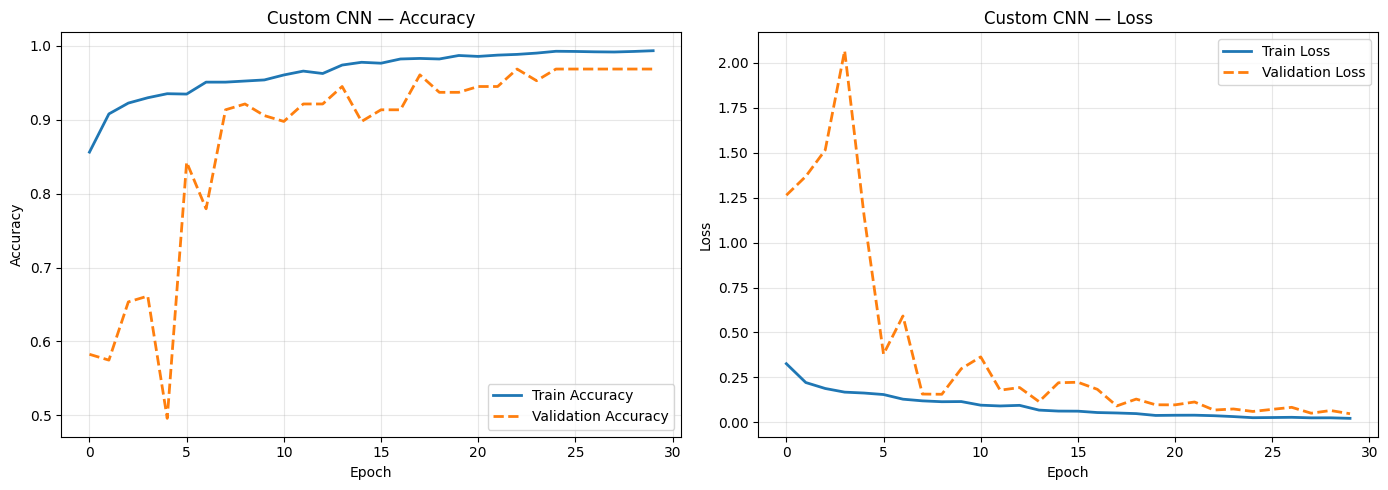


Custom CNN
Accuracy : 0.9977
Precision: 1.0000
Recall   : 0.9961
F1-Score : 0.9981

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.9946    1.0000    0.9973       365
      Rotten     1.0000    0.9961    0.9981       515

    accuracy                         0.9977       880
   macro avg     0.9973    0.9981    0.9977       880
weighted avg     0.9977    0.9977    0.9977       880



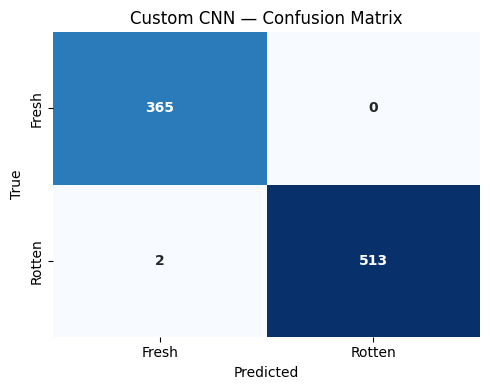

In [18]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f"Custom CNN -> val_loss: {cnn_val_loss:.4f}, val_accuracy: {cnn_val_acc:.4f}")
plot_learning_curves(cnn_history, "Custom CNN")
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, "Custom CNN")

## Model 2: Transfer Learning (MobileNetV3Small)

In [19]:
def build_transfer_model(input_shape, augmentation):
    """
    Feature extraction model:
      1. Augment input (training only)
      2. Preprocess for MobileNetV3 (scales to [-1, 1])
      3. Frozen MobileNetV3Small backbone (no top)
      4. GlobalAveragePooling2D
      5. Dense classification head (binary sigmoid output)
    """
    base_model = tf.keras.applications.MobileNetV3Small(
        weights="imagenet",
        input_shape=input_shape,
        include_top=False,
    )
    base_model.trainable = False
    preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
    print(f"Base model      : {base_model.name}")
    print(f"Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}")
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    return tf.keras.Model(inputs, outputs, name="mobilenetv3small_transfer"), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model      : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,089 (4.15 MB)

 Trainable params: 147,969 (578.00 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [20]:
TL_LR = 1e-4  # Lower LR for transfer learning head
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks("tl_feature_extraction"),
    verbose=1,
)

Epoch 1/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.8668 - loss: 0.3277 - val_accuracy: 0.9606 - val_loss: 0.1423 - learning_rate: 1.0000e-04
Epoch 2/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9704 - loss: 0.1120 - val_accuracy: 0.9764 - val_loss: 0.0989 - learning_rate: 1.0000e-04
Epoch 3/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9806 - loss: 0.0762 - val_accuracy: 0.9843 - val_loss: 0.0821 - learning_rate: 1.0000e-04
Epoch 4/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9809 - loss: 0.0653 - val_accuracy: 0.9764 - val_loss: 0.0672 - learning_rate: 1.0000e-04
Epoch 5/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9809 - loss: 0.0610 - val_accuracy: 0.9843 - val_loss: 0.0588 - learning_rate: 1.0000e-04
Epoch 6/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9883 - loss: 0.0477 - val_accuracy: 0.9764 - val_loss: 0.0635 - learning_rate: 1.0000e-04
Epoch 7/30
126/126 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - ac

MobileNetV3 TL -> val_loss: 0.0306, val_accuracy: 0.9843


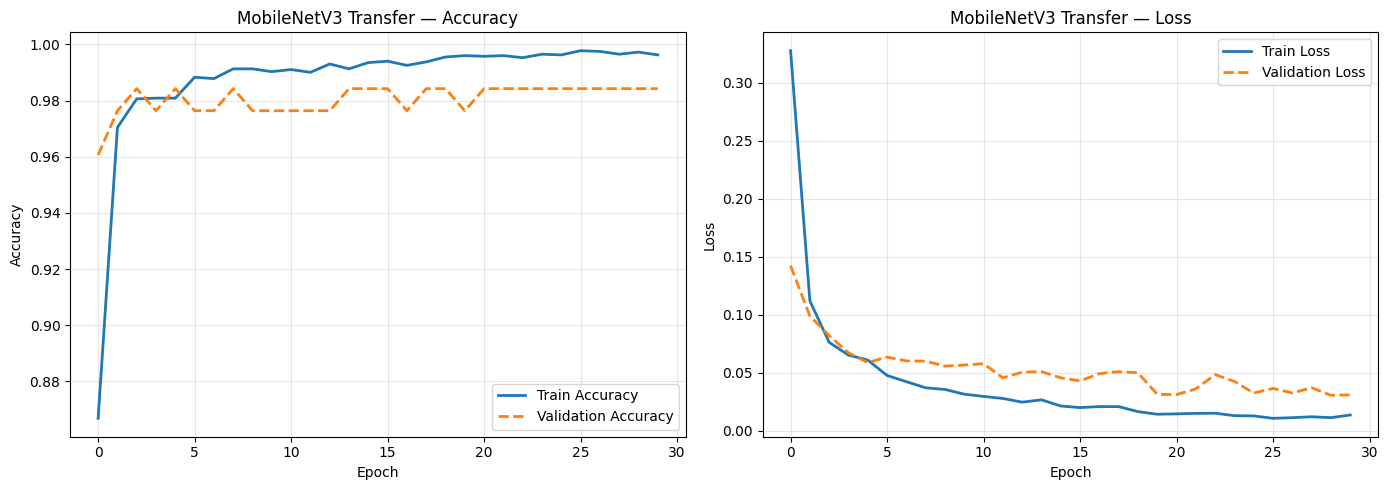


MobileNetV3 Transfer
Accuracy : 0.9920
Precision: 0.9866
Recall   : 1.0000
F1-Score : 0.9932

Classification Report:
              precision    recall  f1-score   support

       Fresh     1.0000    0.9808    0.9903       365
      Rotten     0.9866    1.0000    0.9932       515

    accuracy                         0.9920       880
   macro avg     0.9933    0.9904    0.9918       880
weighted avg     0.9922    0.9920    0.9920       880



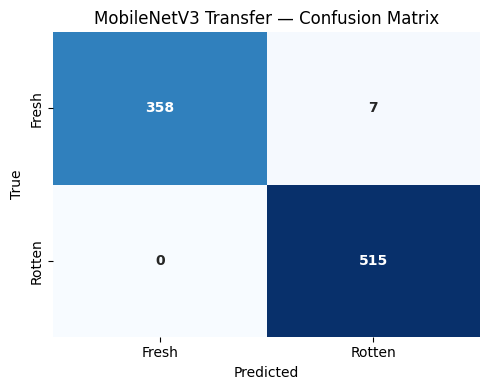

In [21]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f"MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}, val_accuracy: {tl_val_acc:.4f}")
plot_learning_curves(tl_history, "MobileNetV3 Transfer")
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, "MobileNetV3 Transfer")

## Optional: Fine-tuningUnfreezes the top layers of the backbone and continues training at a much lower learning rate. Usually gives a small extra accuracy boost — skip this section if you're short on time/compute.

Trainable base layers after unfreezing: 30 / 157
Epoch 1/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9448 - loss: 0.1737 - val_accuracy: 0.9606 - val_loss: 0.0620 - learning_rate: 1.0000e-05
Epoch 2/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.9826 - loss: 0.0435 - val_accuracy: 0.9528 - val_loss: 0.0769 - learning_rate: 1.0000e-05
Epoch 3/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9833 - loss: 0.0416 - val_accuracy: 0.9606 - val_loss: 0.0696 - learning_rate: 1.0000e-05
Epoch 4/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9861 - loss: 0.0351 - val_accuracy: 0.9685 - val_loss: 0.0573 - learning_rate: 1.0000e-05
Epoch 5/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9873 - loss: 0.0368 - val_accuracy: 0.9843 - val_loss: 0.0308 - learning_rate: 1.0000e-05
Epoch 6/15
126/126 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9920 - loss: 0.0242 - val_accuracy: 0.9843 - val_loss: 0.0225 - learning_rate: 1.0000e-05
Epoch 7/

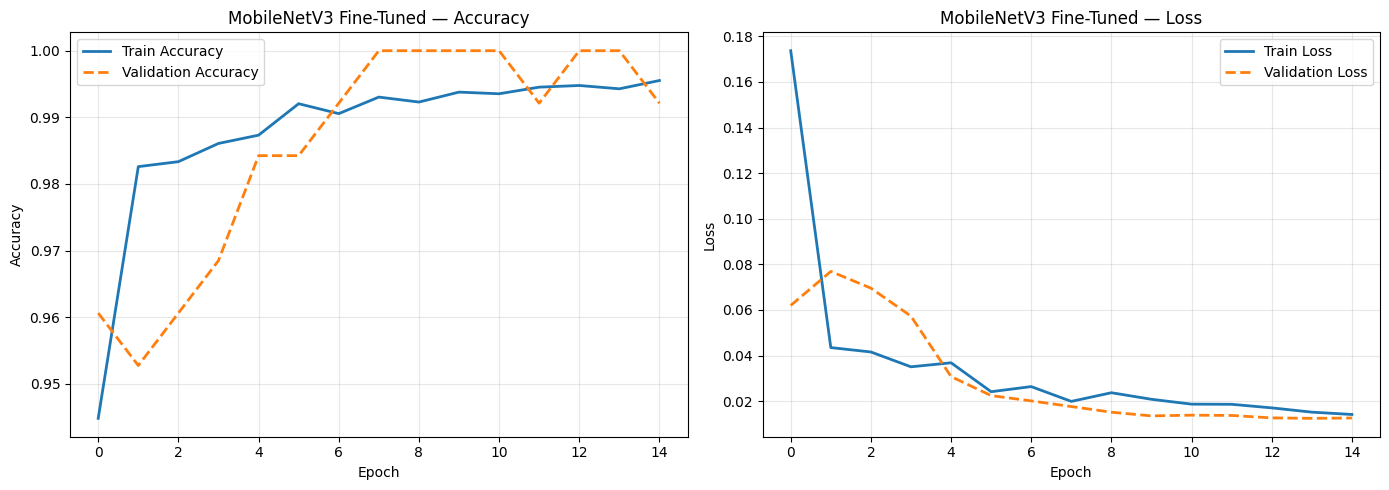


MobileNetV3 Fine-Tuned
Accuracy : 0.9989
Precision: 1.0000
Recall   : 0.9981
F1-Score : 0.9990

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.9973    1.0000    0.9986       365
      Rotten     1.0000    0.9981    0.9990       515

    accuracy                         0.9989       880
   macro avg     0.9986    0.9990    0.9988       880
weighted avg     0.9989    0.9989    0.9989       880



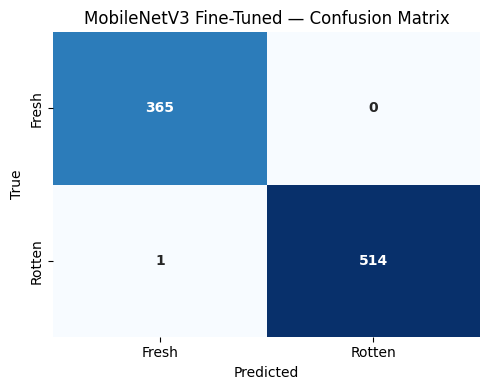

In [22]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}")
FINETUNE_LR = TL_LR / 10
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=make_callbacks("tl_finetuned"),
    verbose=1,
)
plot_learning_curves(ft_history, "MobileNetV3 Fine-Tuned")
ft_test_acc = evaluate_model(tl_model, test_dataset, class_names, "MobileNetV3 Fine-Tuned")

## Model comparison

In [23]:
results = {    "Custom CNN": {"acc": cnn_test_acc, "params": cnn_model.count_params()},    "MobileNetV3 (TL)": {"acc": tl_test_acc, "params": tl_model.count_params()},}# If you ran the fine-tuning cell, this adds the fine-tuned result tooif "ft_test_acc" in globals():    results["MobileNetV3 (FT)"] = {"acc": ft_test_acc, "params": tl_model.count_params()}print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')print("-" * 55)for name, vals in results.items():    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')labels = list(results.keys())accs = [v["acc"] * 100 for v in results.values()]fig, ax = plt.subplots(figsize=(8, 5))bars = ax.bar(labels, accs, color=["#e06c75", "#61afef", "#98c379"][:len(labels)], edgecolor="black", width=0.5)ax.set_ylim(min(accs) - 10, 100)ax.set_ylabel("Test Accuracy (%)")ax.set_title("Fresh vs Rotten Apple: Model Comparison")ax.grid(axis="y", alpha=0.3)for bar, acc in zip(bars, accs):    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{acc:.2f}%", ha="center", fontweight="bold")plt.tight_layout()plt.savefig(results_dir + "model_comparison.png", dpi=120, bbox_inches="tight")plt.show()

## Test on a single image

In [24]:
def predict_image(img_path, model, class_names, image_size=(IMAGE_HEIGHT, IMAGE_WIDTH)):
    """Load an image file and classify it with the model."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    prob = model.predict(img_array, verbose=0)[0][0]
    label = class_names[int(prob >= 0.5)]
    print(f"Prediction: {label}  (p={prob:.4f})")

# Uncomment and supply a real image path to test:
# predict_image("path/to/your/apple_image.jpg", tl_model, class_names)

## Save the trained modelThis is the file Lab 10's `app.py` will load for the Streamlit deployment.

In [25]:
os.makedirs("models", exist_ok=True)
cnn_model.save("models/custom_cnn.keras")
tl_model.save("models/apple_classifier.keras")   # use this one in app.py — it's the stronger model
print("Models saved:")
print(" models/custom_cnn.keras")
print(" models/apple_classifier.keras")

Models saved:
 models/custom_cnn.keras
 models/apple_classifier.keras


In [26]:
from google.colab import files

files.download('models/custom_cnn.keras')
files.download('models/apple_classifier.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>